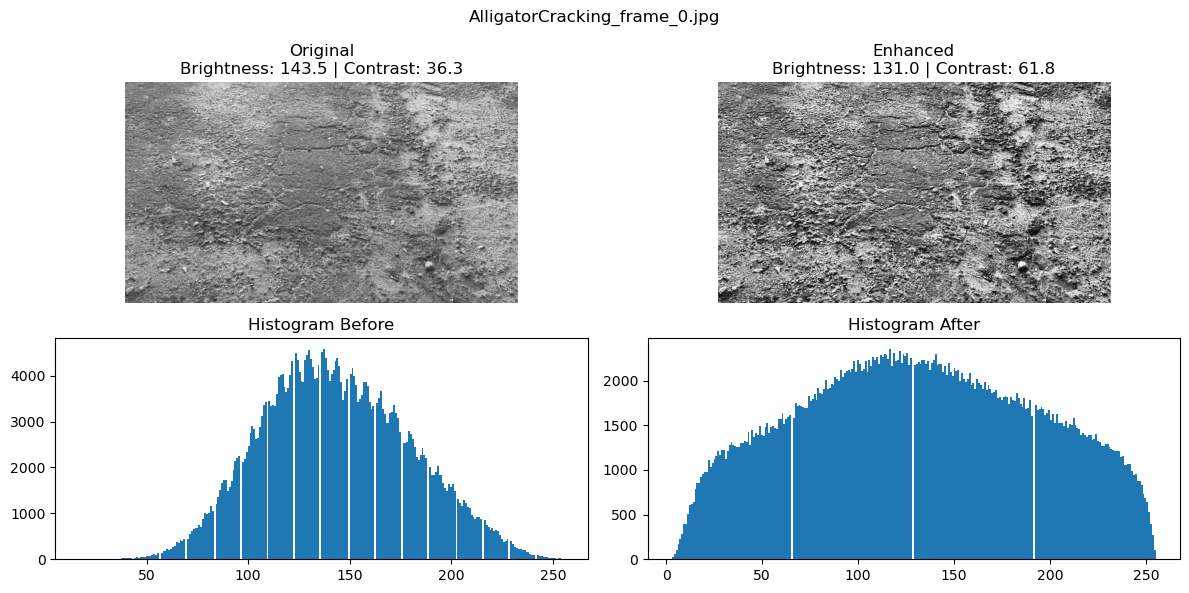

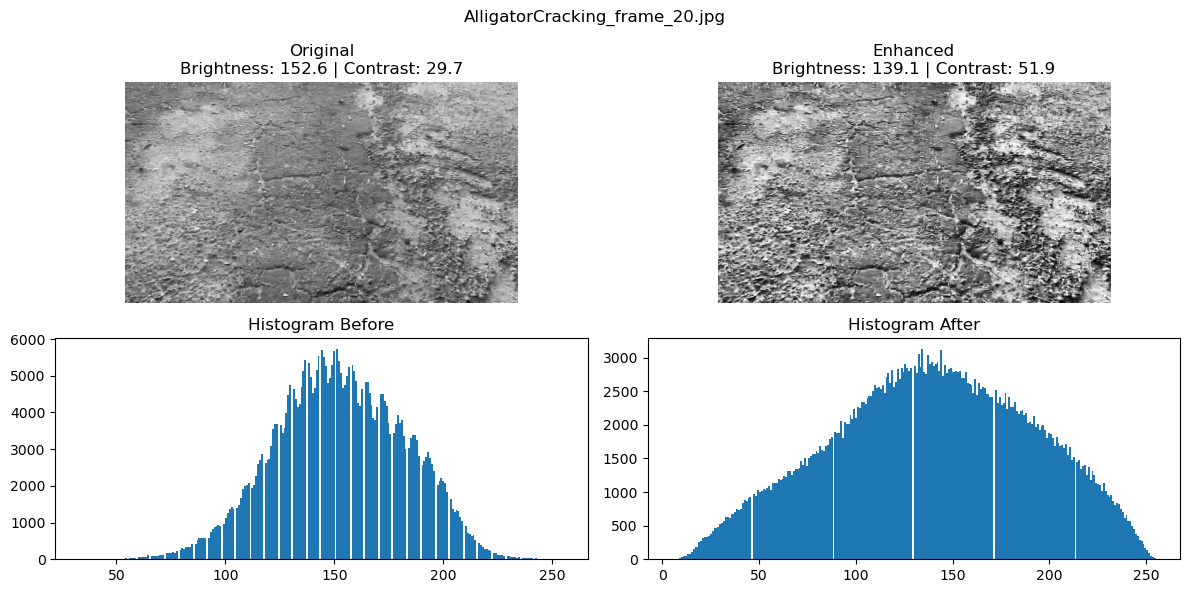

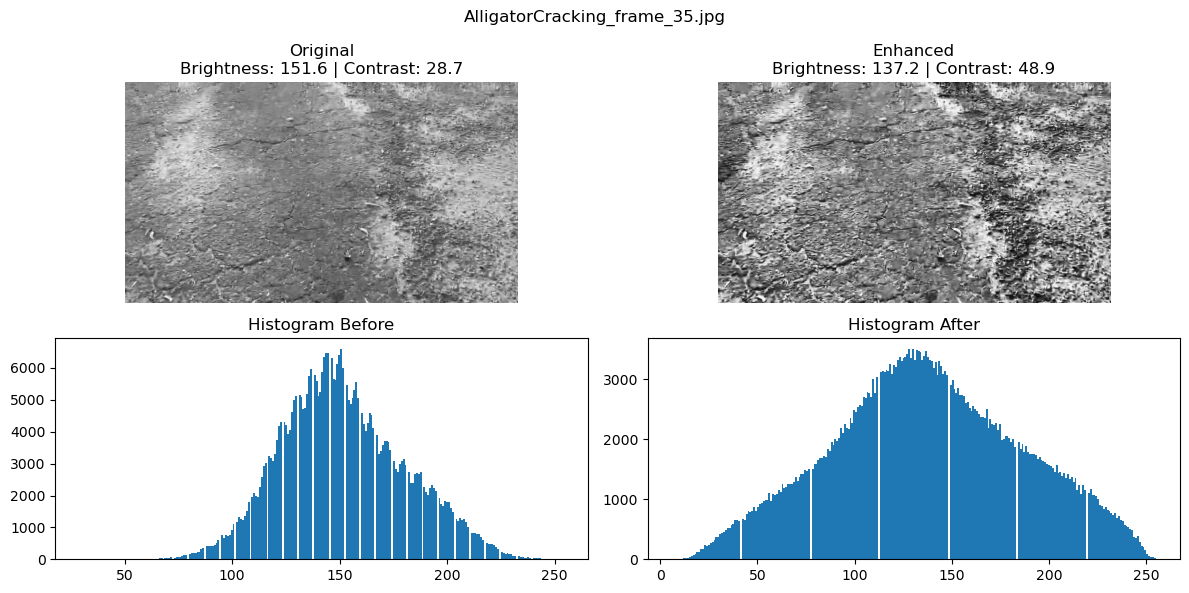

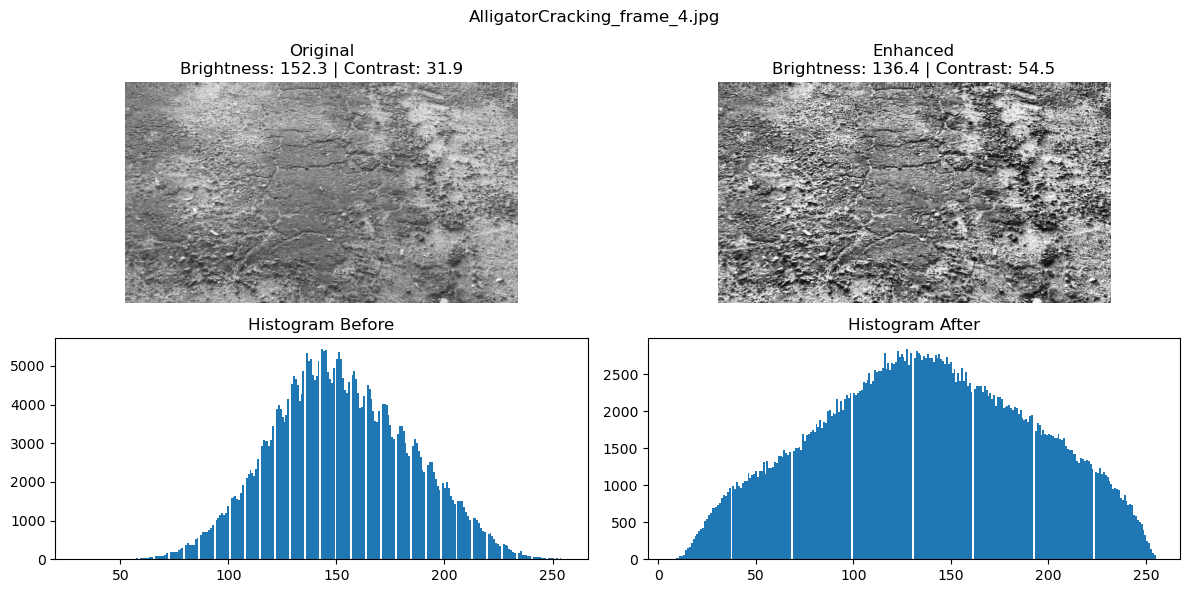

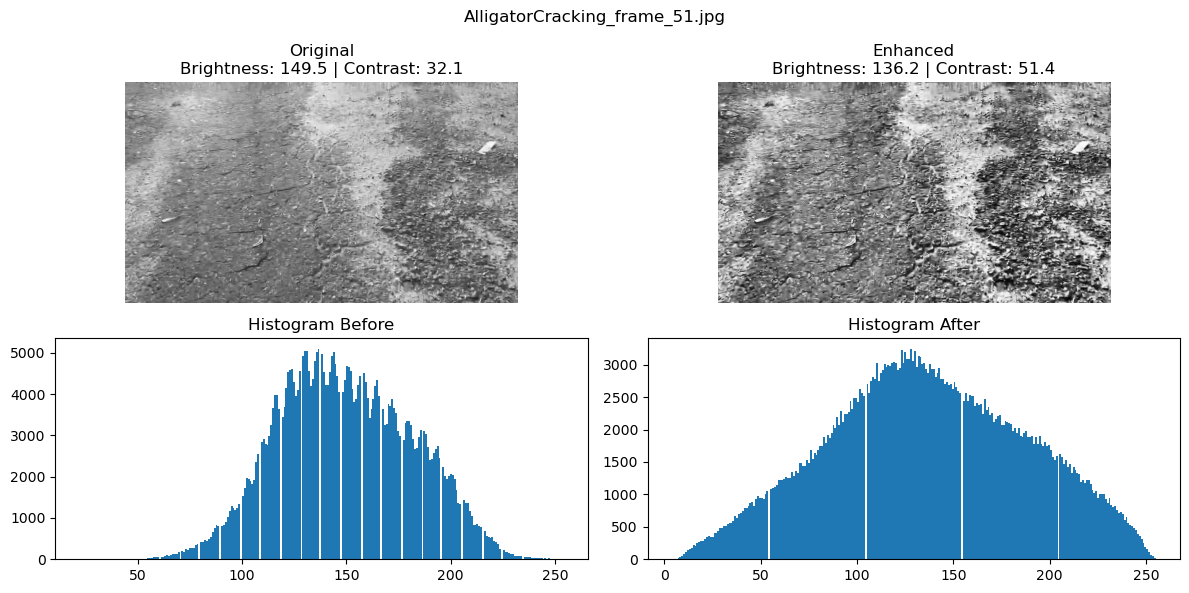

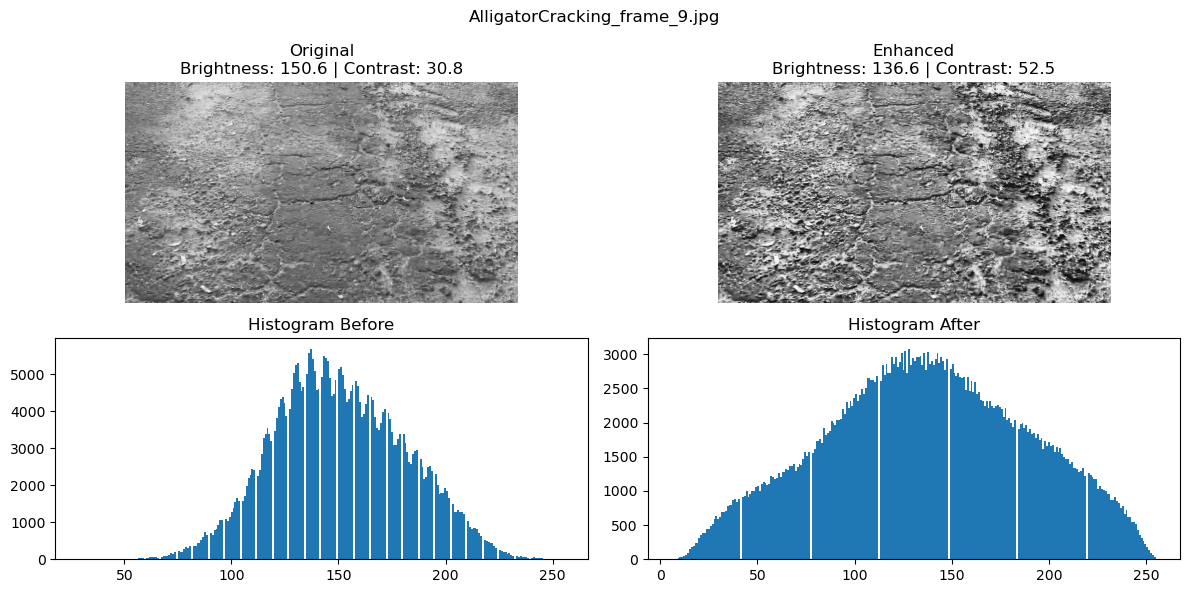

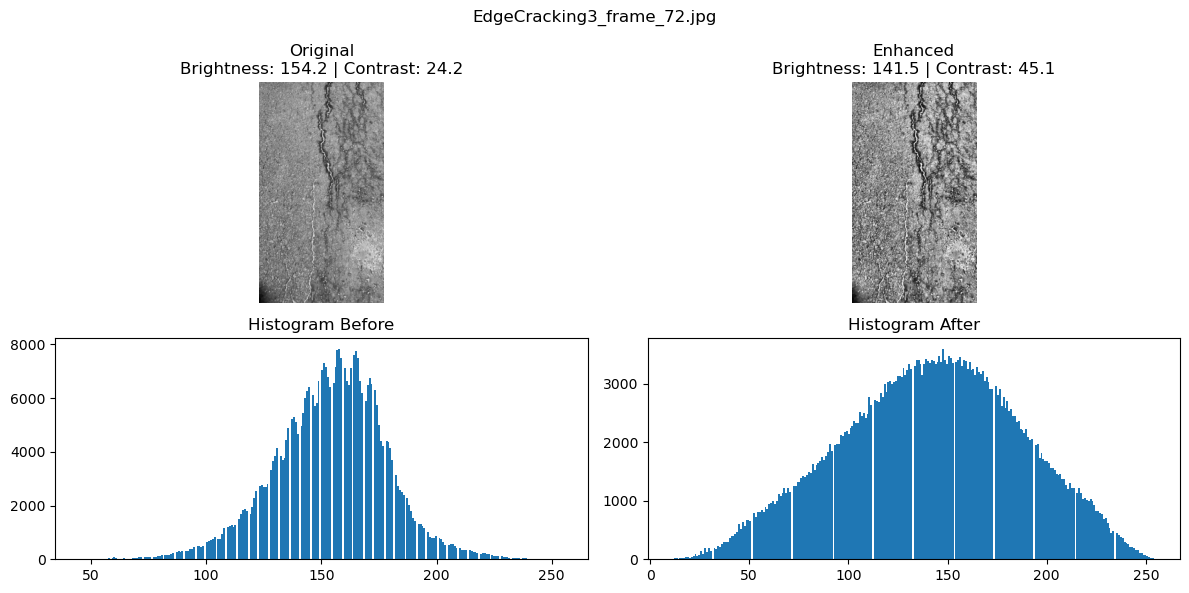

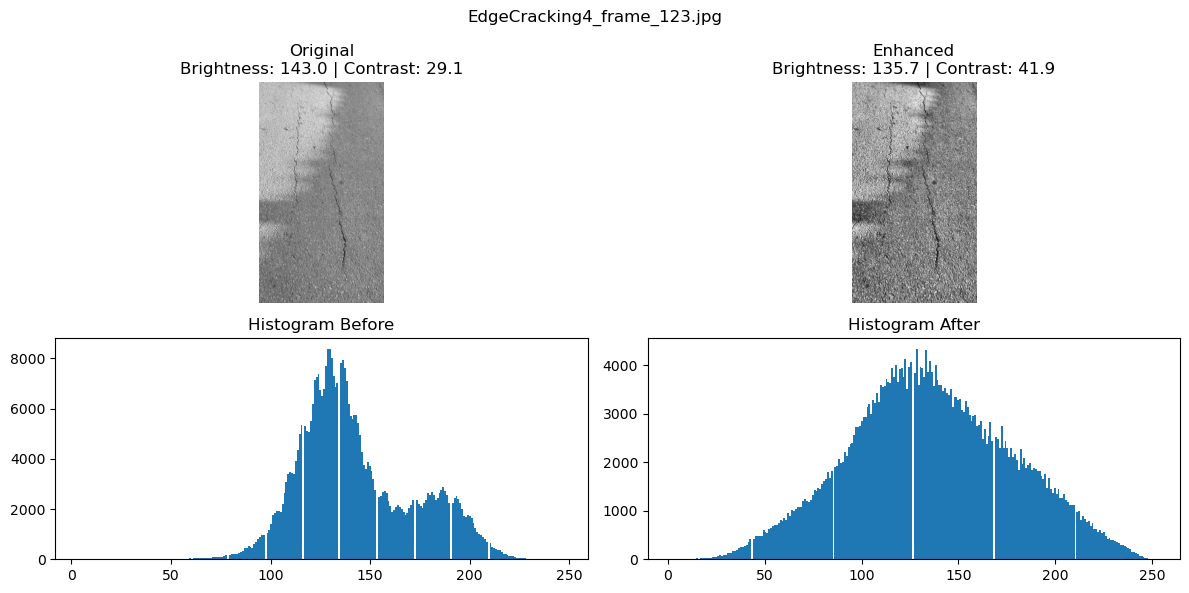

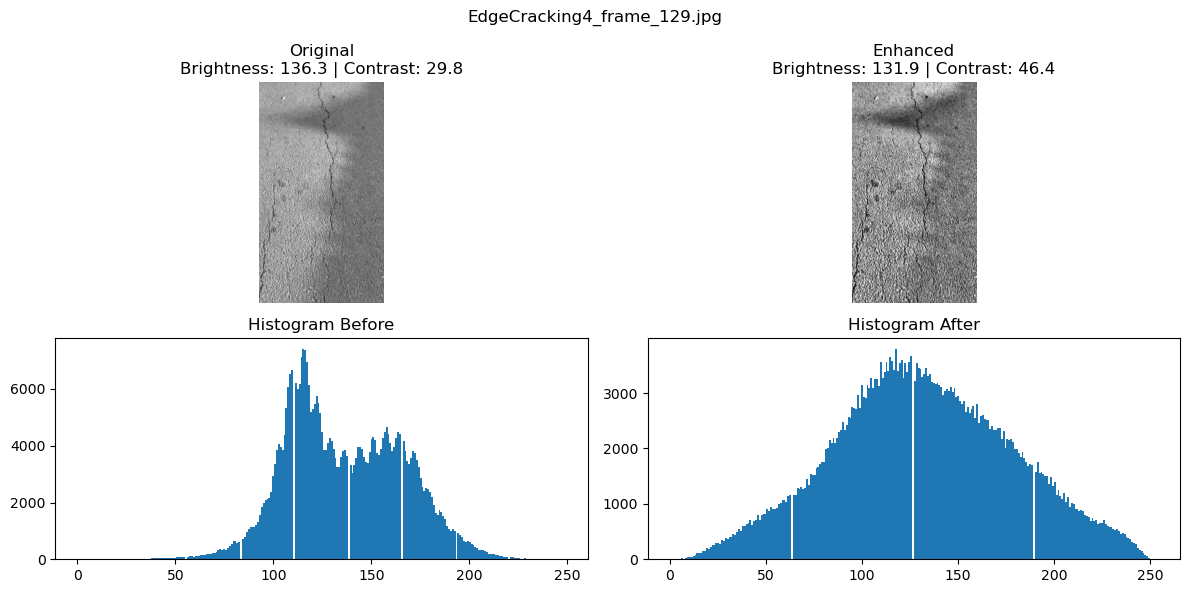

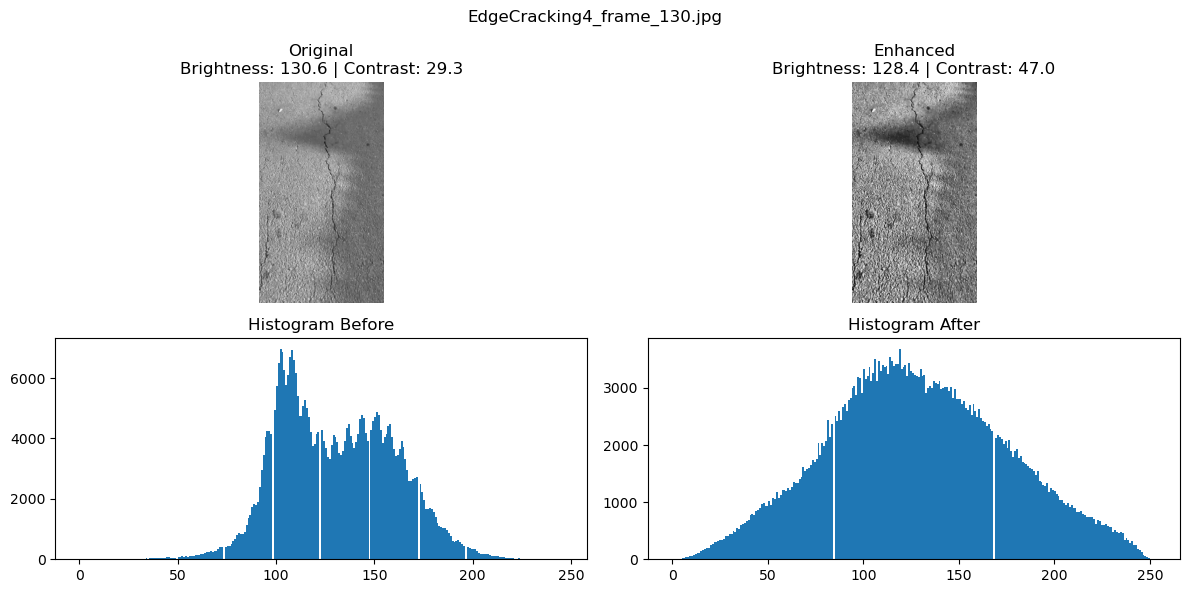

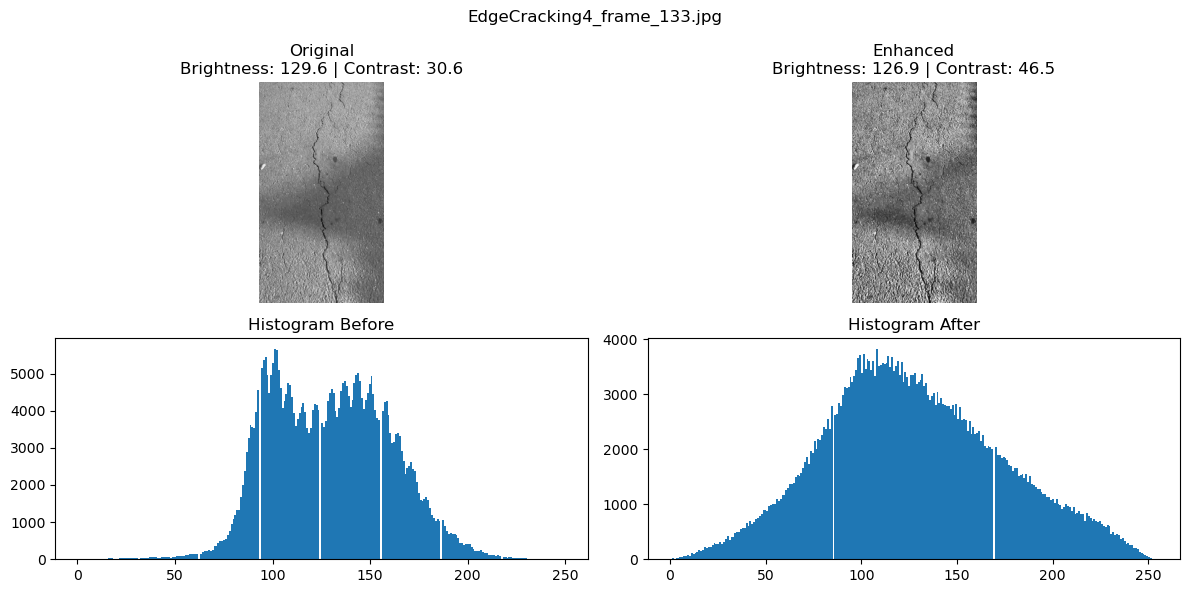

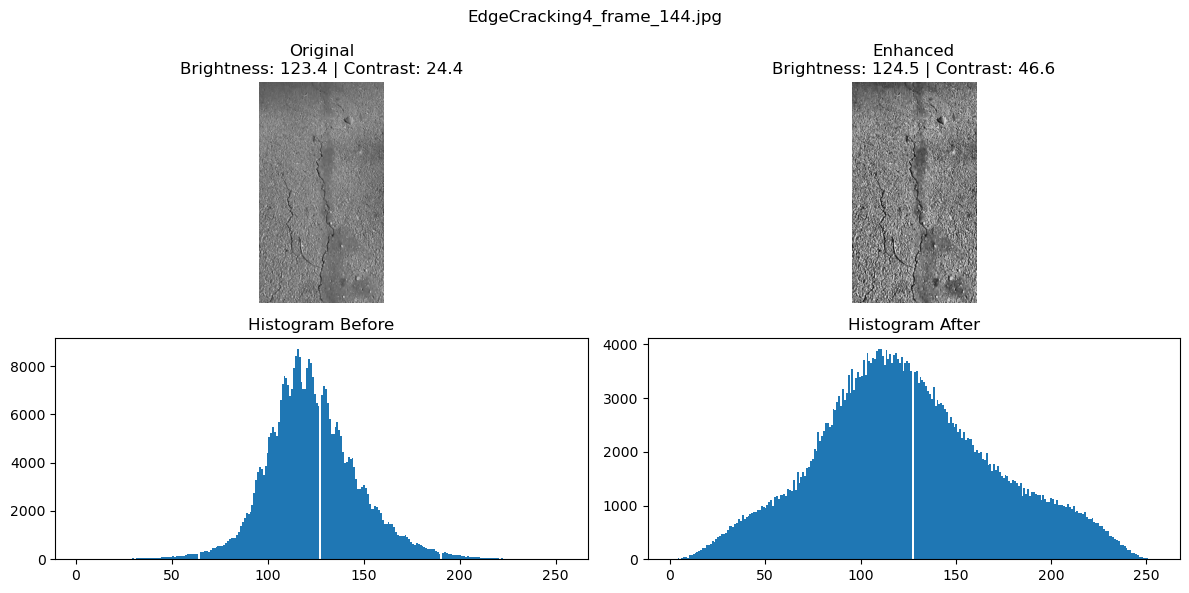

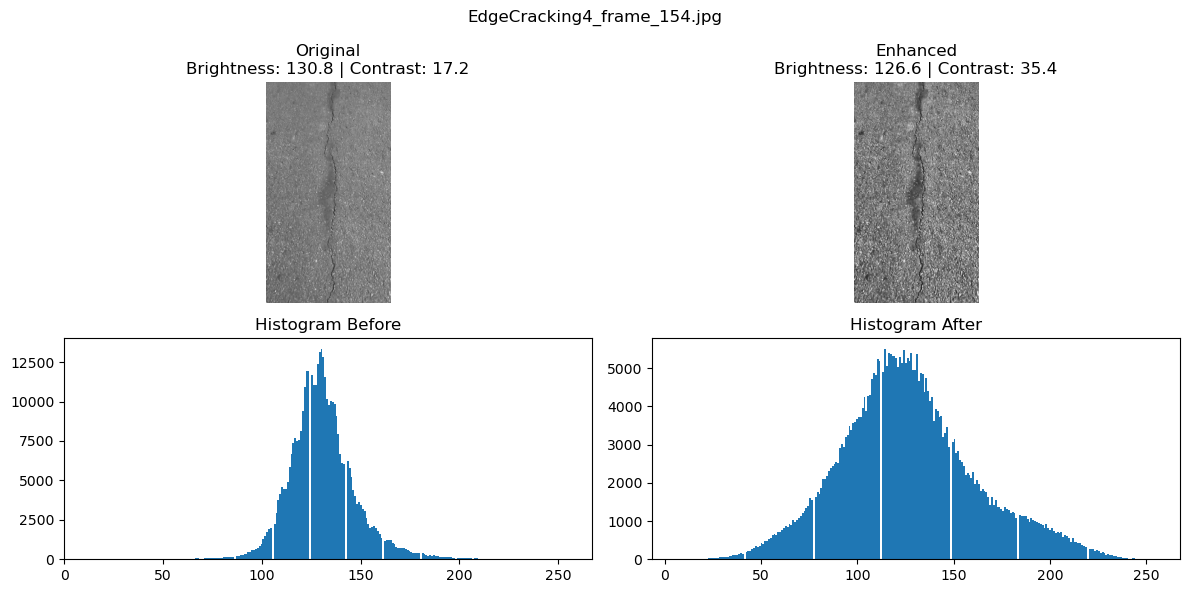

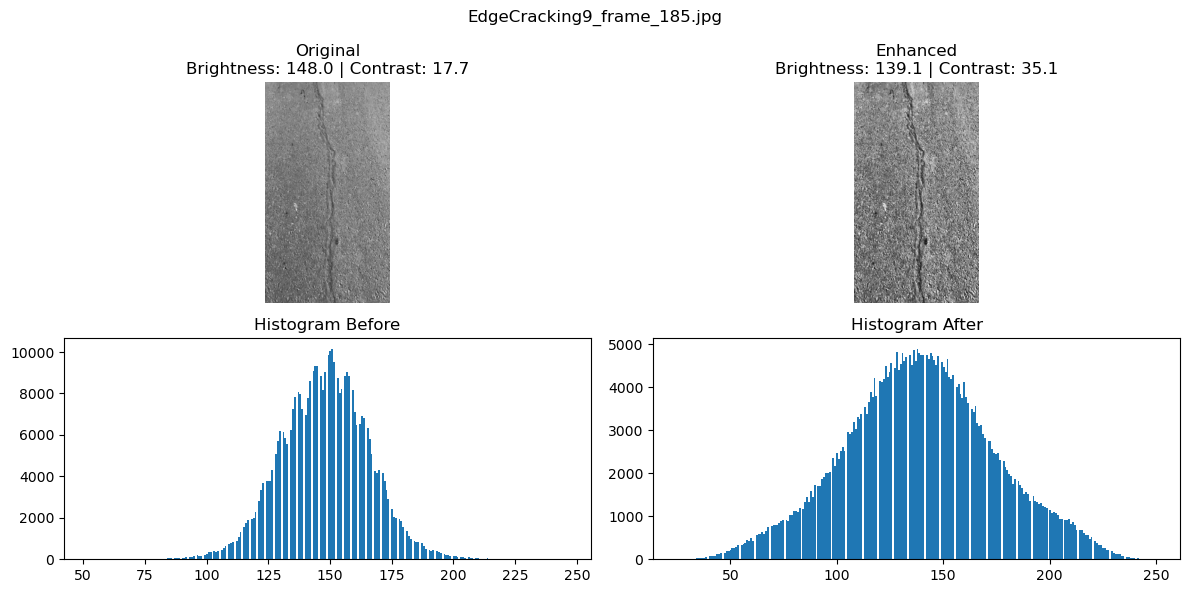

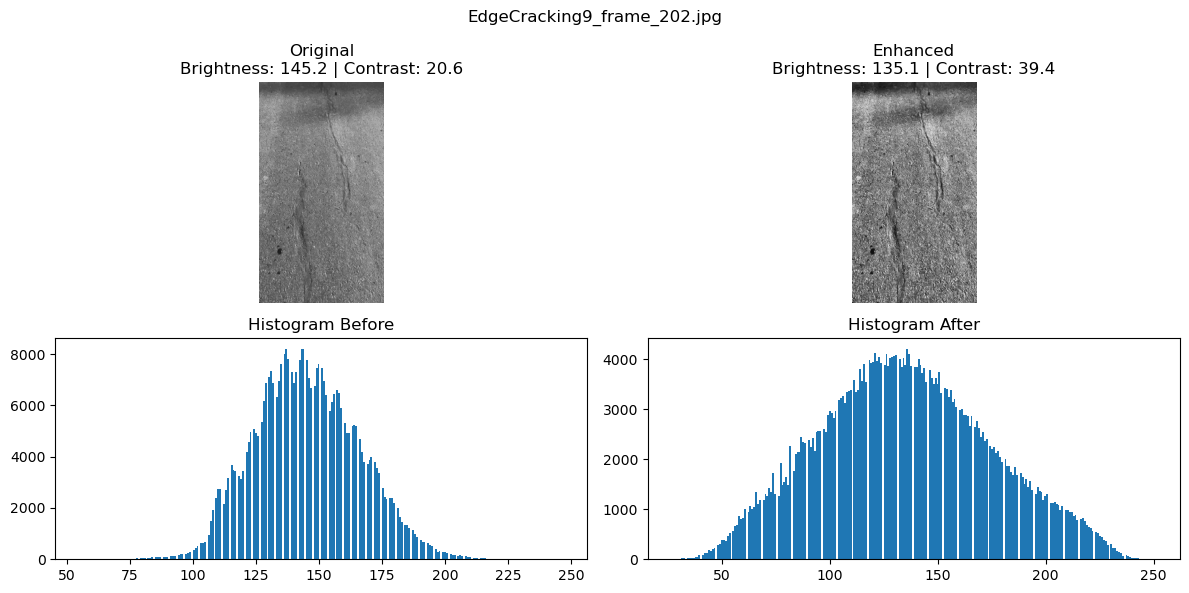

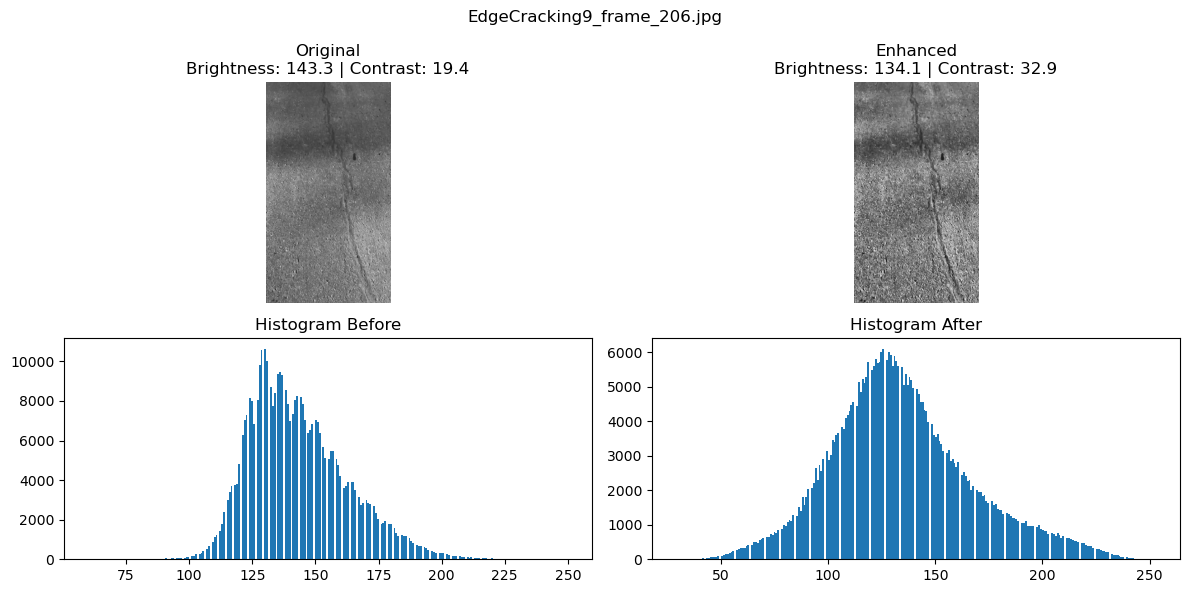

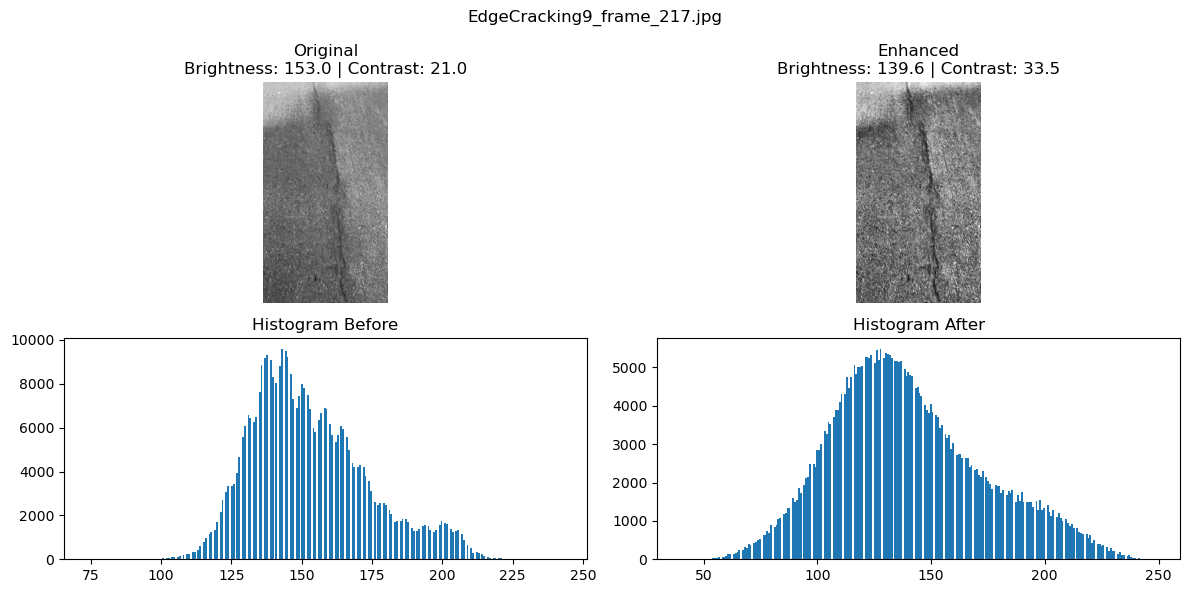

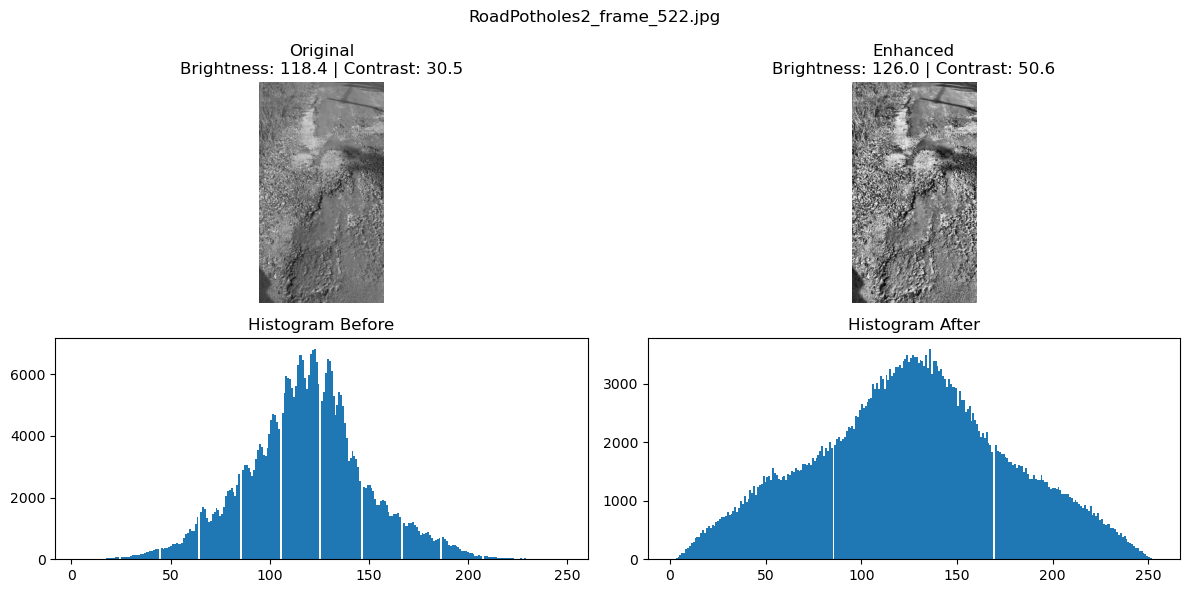

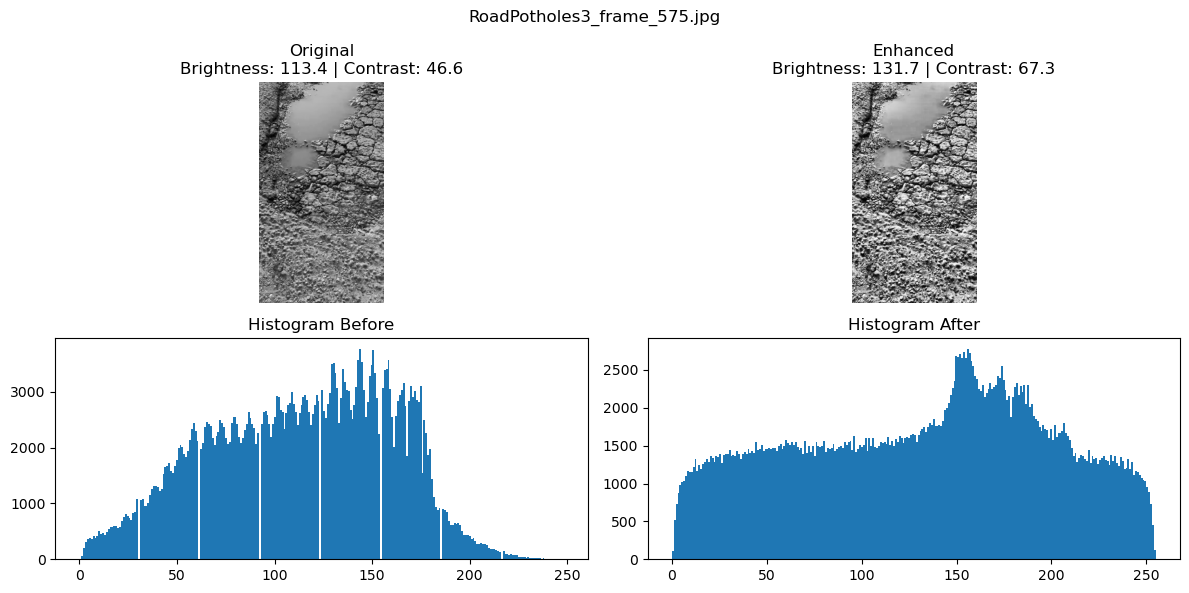

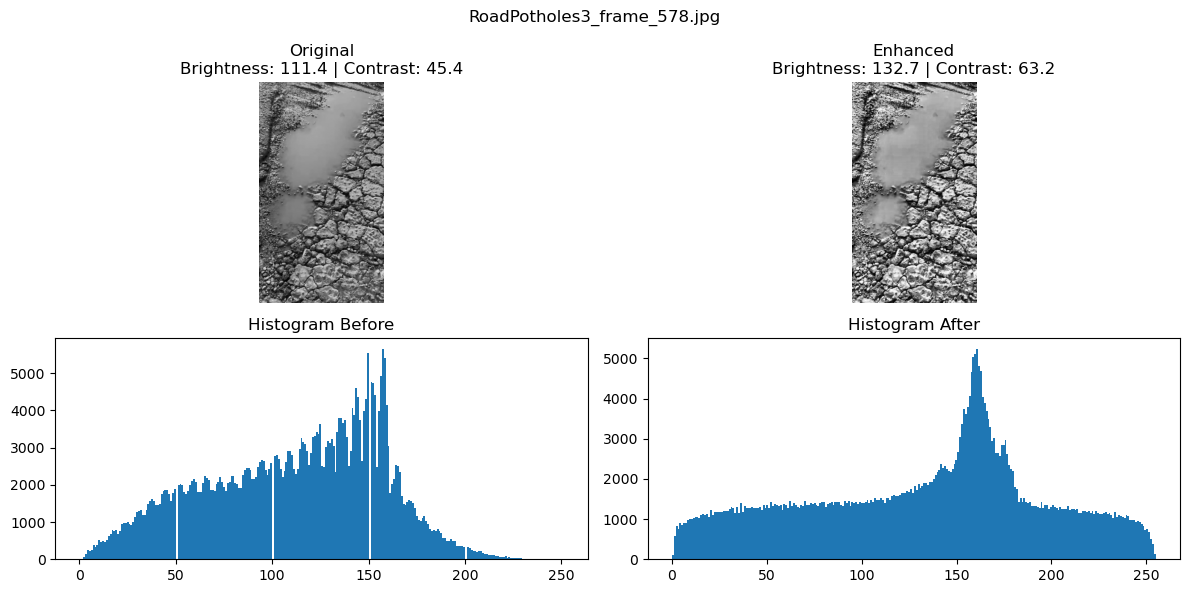

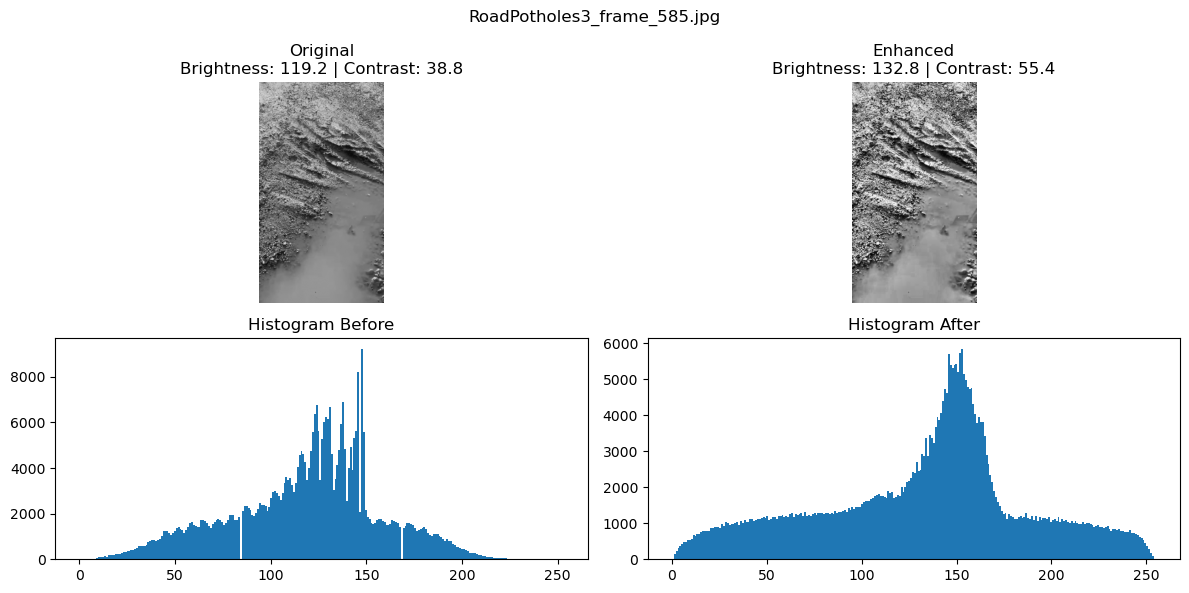

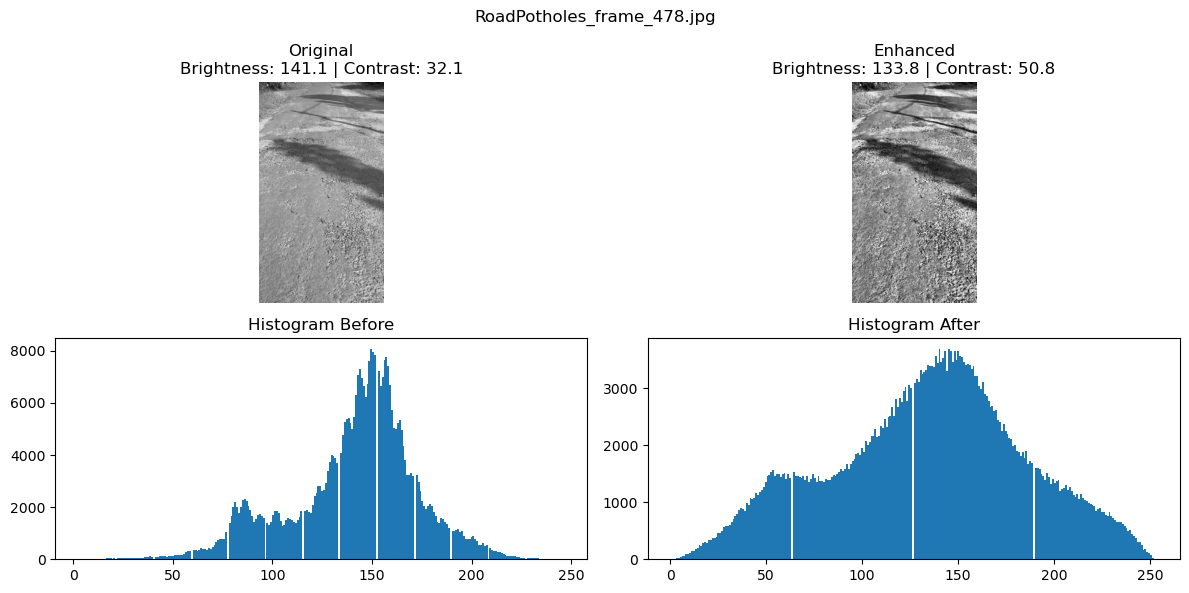

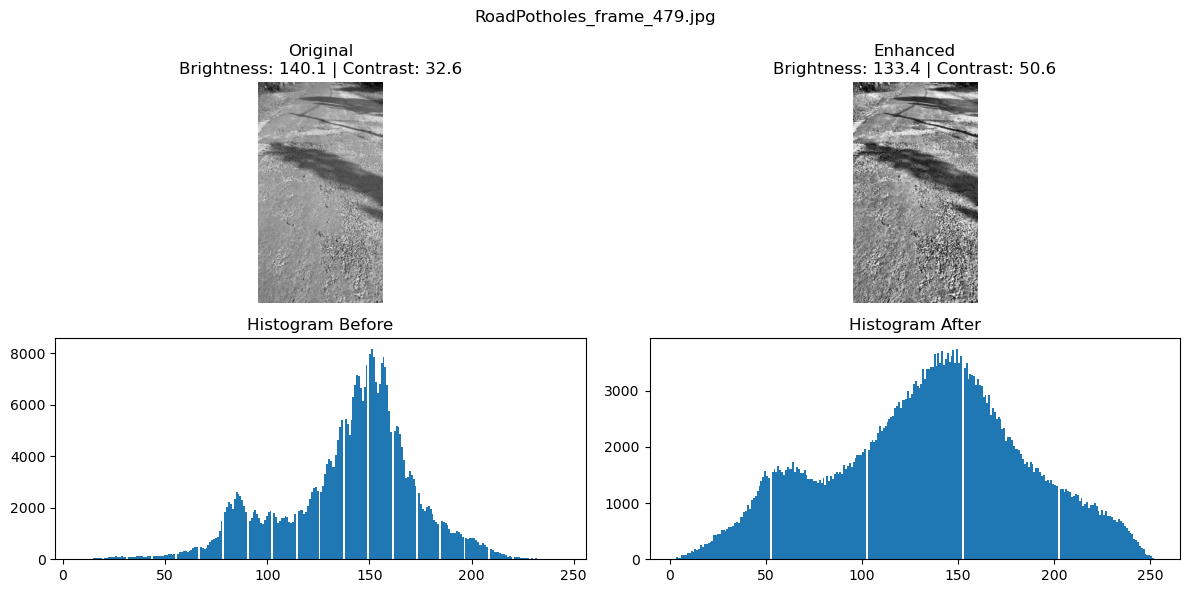

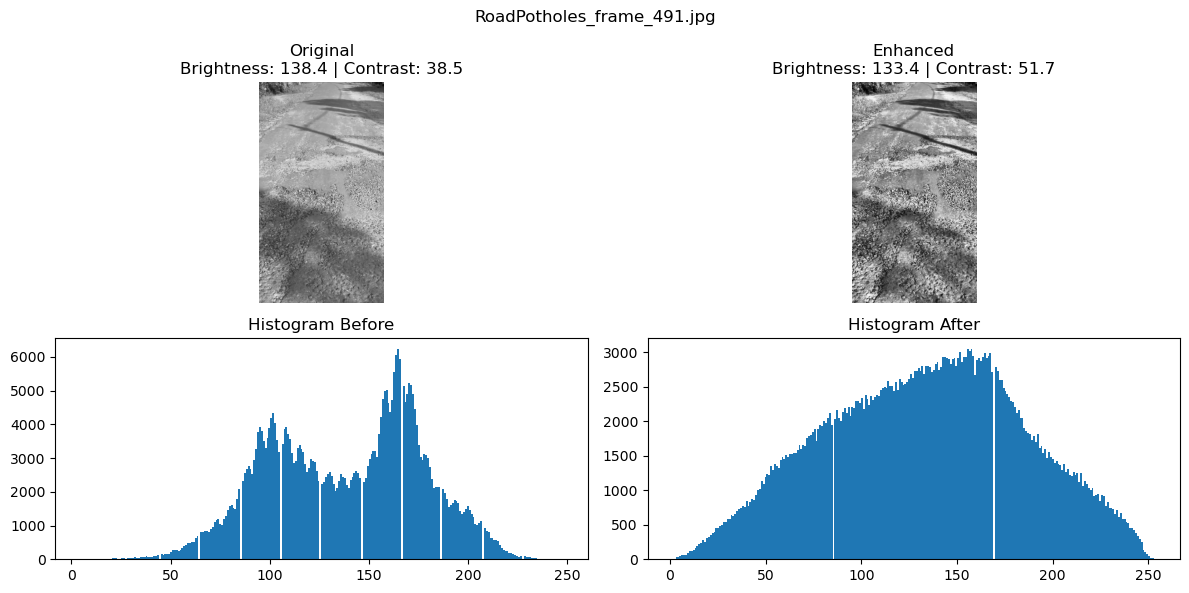

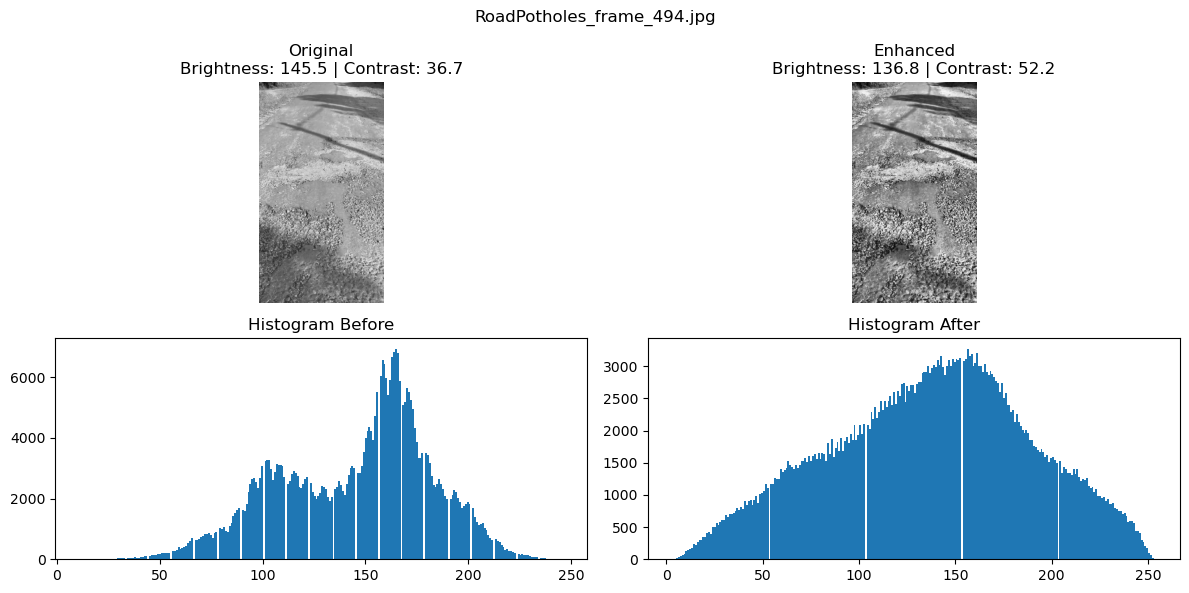

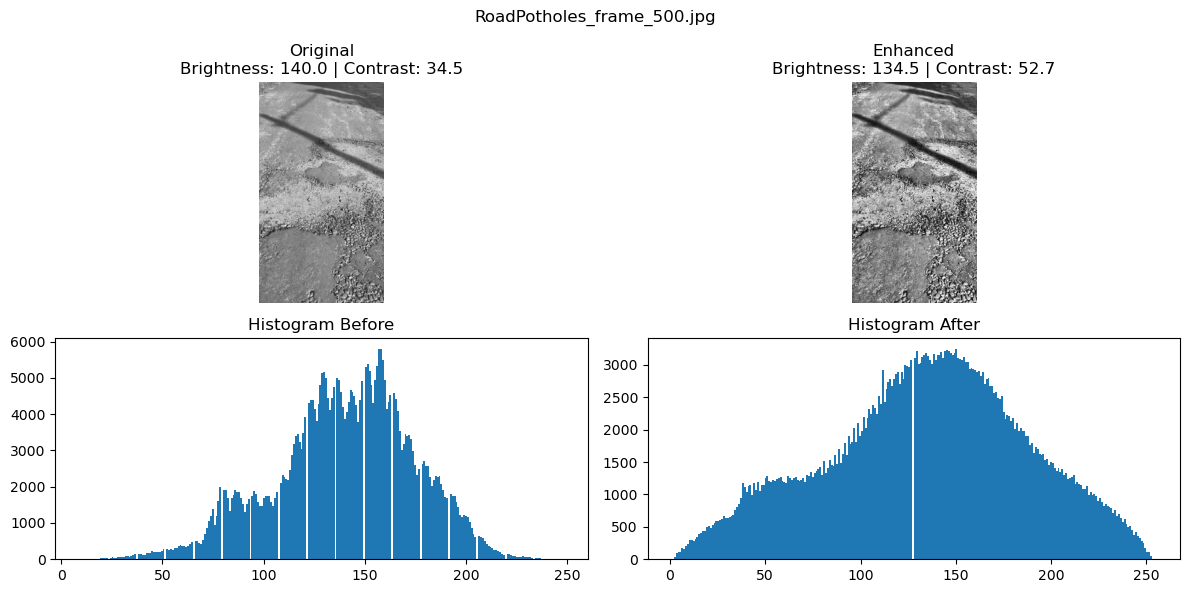

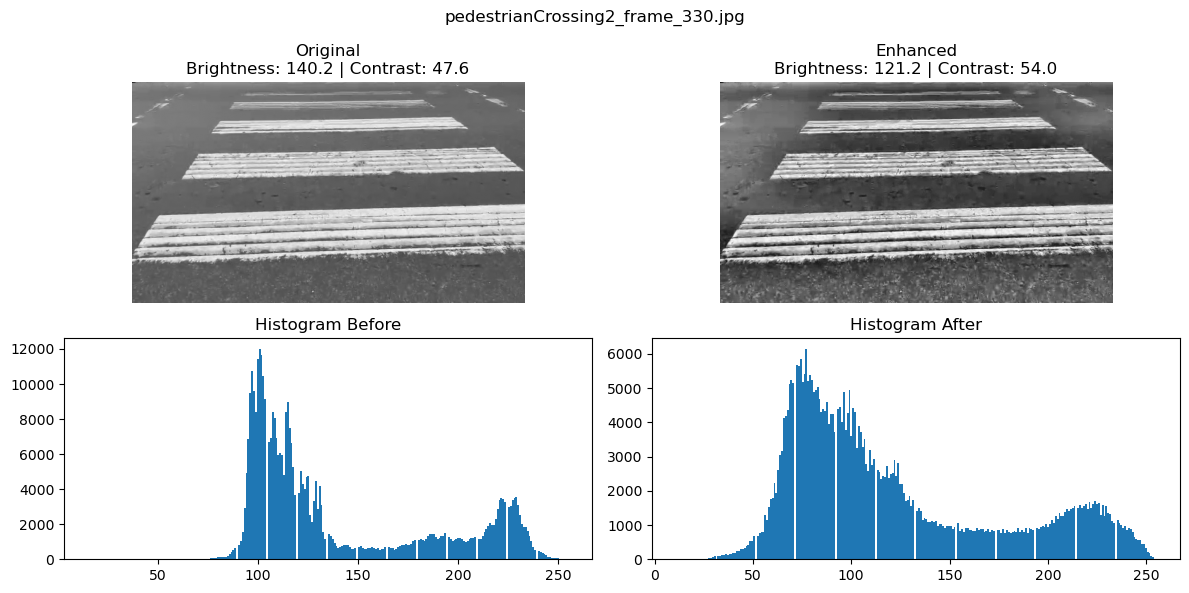

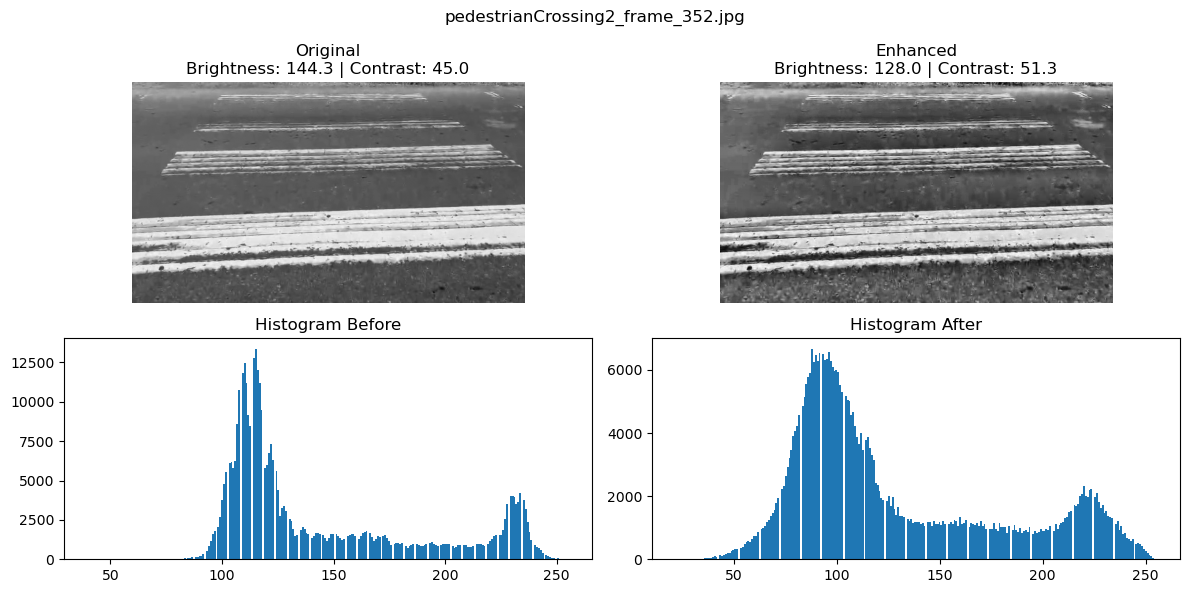

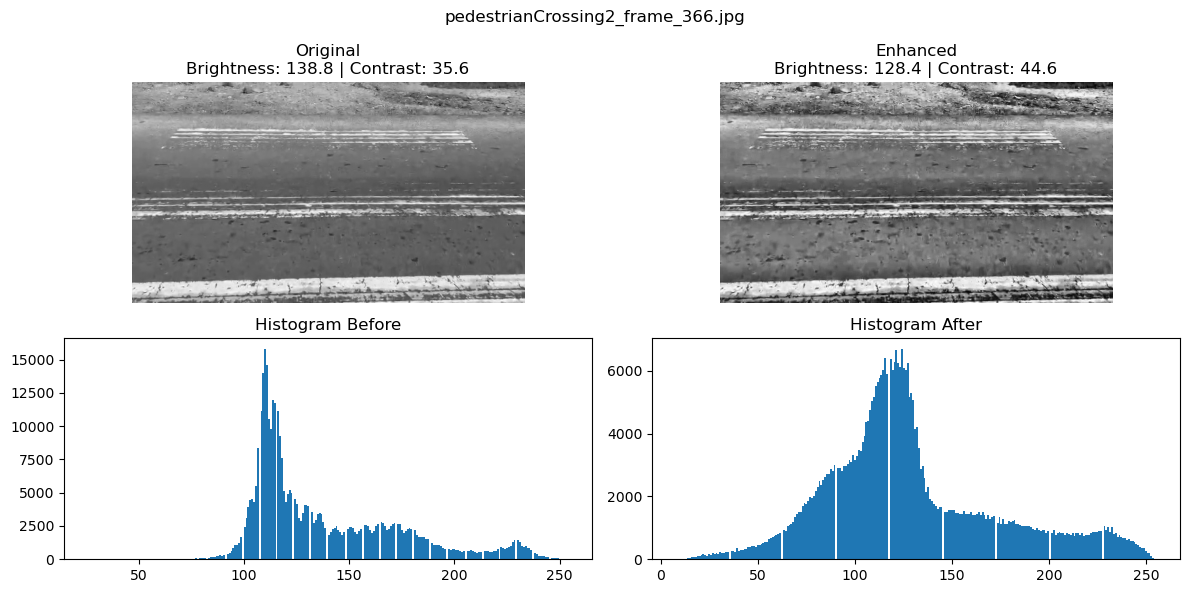

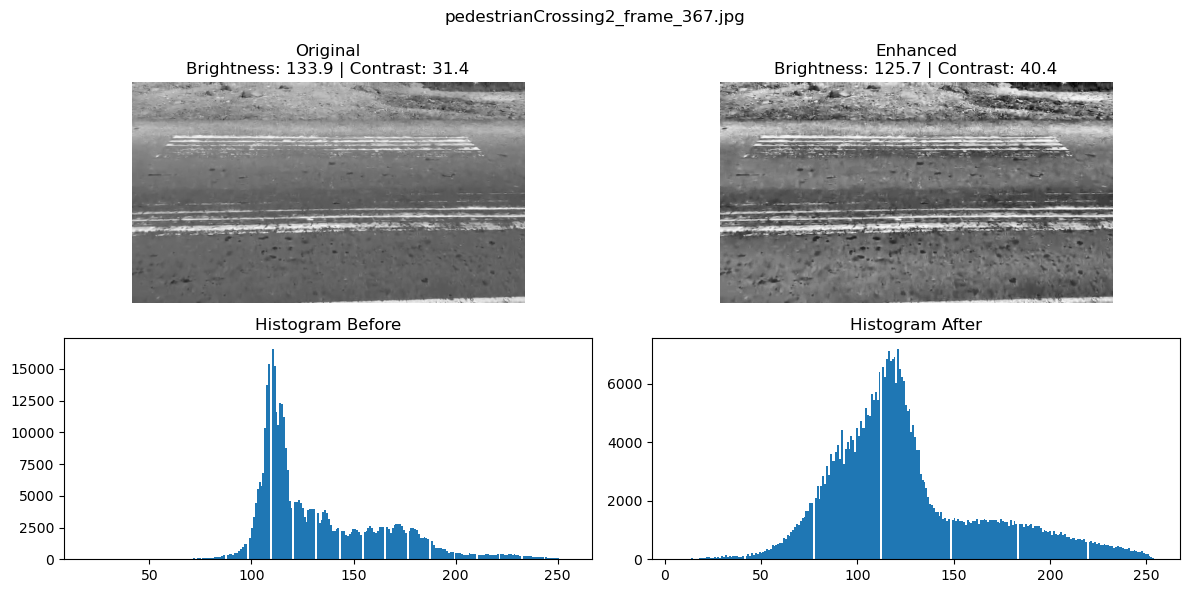


================ ILLUMINATION ANALYSIS TABLE ================

Frame                              Issue          Brightness B   Brightness A   Contrast B     Contrast A     Improved    
--------------------------------------------------------------------------------------------------------------------------
AlligatorCracking_frame_0.jpg      Normal         143.5          131.0          36.3           61.8           Yes         
AlligatorCracking_frame_20.jpg     Normal         152.6          139.1          29.7           51.9           Yes         
AlligatorCracking_frame_35.jpg     Normal         151.6          137.2          28.7           48.9           Yes         
AlligatorCracking_frame_4.jpg      Normal         152.3          136.4          31.9           54.5           Yes         
AlligatorCracking_frame_51.jpg     Normal         149.5          136.2          32.1           51.4           Yes         
AlligatorCracking_frame_9.jpg      Normal         150.6          136.6     

In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

frames_folder = "frames"

def apply_clahe(gray):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    return clahe.apply(gray)

def gamma_correction(image, gamma=1.2):
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255
                      for i in np.arange(256)]).astype("uint8")
    return cv2.LUT(image, table)

def calculate_contrast(image):
    return np.std(image)

def show_results(original, enhanced, file_name, b_before, b_after, c_before, c_after):

    plt.figure(figsize=(12,6))

    plt.subplot(2,2,1)
    plt.imshow(original, cmap="gray")
    plt.title(f"Original\nBrightness: {round(b_before,1)} | Contrast: {round(c_before,1)}")
    plt.axis("off")

    plt.subplot(2,2,2)
    plt.imshow(enhanced, cmap="gray")
    plt.title(f"Enhanced\nBrightness: {round(b_after,1)} | Contrast: {round(c_after,1)}")
    plt.axis("off")

    plt.subplot(2,2,3)
    plt.hist(original.ravel(), bins=256)
    plt.title("Histogram Before")

    plt.subplot(2,2,4)
    plt.hist(enhanced.ravel(), bins=256)
    plt.title("Histogram After")

    plt.suptitle(file_name)
    plt.tight_layout()
    plt.show()

frame_files = sorted(os.listdir(frames_folder))

display_count = 0
max_display = 30

results_table = []

for file in frame_files:

    if not file.lower().endswith((".jpg", ".png", ".jpeg")):
        continue

    path = os.path.join(frames_folder, file)
    img = cv2.imread(path)

    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    brightness_before = np.mean(gray)
    contrast_before = calculate_contrast(gray)

    if brightness_before < 100:
        gamma = 1.5
        issue = "Low Light"
    elif brightness_before > 180:
        gamma = 0.7
        issue = "Overexposed"
    else:
        gamma = 1.0
        issue = "Normal"

    enhanced = apply_clahe(gray)
    enhanced = gamma_correction(enhanced, gamma)

    brightness_after = np.mean(enhanced)
    contrast_after = calculate_contrast(enhanced)

    contrast_improved = "Yes" if contrast_after > contrast_before else "No"

    results_table.append([
        file,
        issue,
        round(brightness_before,1),
        round(brightness_after,1),
        round(contrast_before,1),
        round(contrast_after,1),
        contrast_improved
    ])


    if display_count < max_display:
        show_results(gray, enhanced, file,
                     brightness_before, brightness_after,
                     contrast_before, contrast_after)
        display_count += 1


print("\n================ ILLUMINATION ANALYSIS TABLE ================\n")

col_widths = [35, 15, 15, 15, 15, 15, 12]

header = ["Frame", "Issue", "Brightness B", "Brightness A", "Contrast B", "Contrast A", "Improved"]

def format_row(row, widths):
    formatted = ""
    for i, item in enumerate(row):
        item = str(item)
        if i == 0 and len(item) > widths[i]:
            item = item[:widths[i]-3] + "..."
        formatted += item.ljust(widths[i])
    return formatted

print(format_row(header, col_widths))
print("-" * sum(col_widths))

for row in results_table:
    print(format_row(row, col_widths))

print("\nIllumination & Contrast Enhancement Completed")